In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Task A
data = load_diabetes(as_frame=True)

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

display(X.head())
display((X_train.shape, X_test.shape))
display(y_train.describe())

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


((353, 10), (89, 10))

count    353.000000
mean     153.736544
std       78.061902
min       25.000000
25%       86.000000
50%      142.000000
75%      214.000000
max      346.000000
Name: target, dtype: float64

In [3]:
# Task B
def evaluate_regression(model_name, model, X_train, X_test, y_train, y_test):
    pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2  = r2_score(y_test, preds)
    
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

In [4]:
# Task C
models = [
    ("LinearRegression", LinearRegression()),
    ("DecisionTree_depth_3", DecisionTreeRegressor(max_depth=3, random_state=42)),
    ("DecisionTree_unlimited", DecisionTreeRegressor(random_state=42)),
    ("RandomForest", RandomForestRegressor(n_estimators=100, random_state=42)),
]

results = []

for model in models:
    model_name = model[0]
    model_type = model[1]

    results.append(evaluate_regression(model_name, model_type, X_train, X_test, y_train, y_test))


base_results_df = pd.DataFrame(results).sort_values("MAE")
print(base_results_df)

                    model        MAE       RMSE        R2
0        LinearRegression  42.794095  53.853446  0.452603
3            RandomForest  44.171236  54.398351  0.441469
1    DecisionTree_depth_3  48.096592  59.604541  0.329445
2  DecisionTree_unlimited  53.921348  69.907081  0.077603


In [5]:
# Task D
models = [
    ("DecisionTree_depth_3", DecisionTreeRegressor(max_depth=3, random_state=42)),
    ("DecisionTree_unlimited", DecisionTreeRegressor(random_state=42)),
]


results = []

for name, model in models:

    pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)

    train_preds = pipeline.predict(X_train)
    test_preds  = pipeline.predict(X_test)

    train_mae  = mean_absolute_error(y_train, train_preds)
    test_mae   = mean_absolute_error(y_test, test_preds)

    results.append({
        "model": name,
        "train_MAE": train_mae,
        "test_MAE": test_mae
    })


results_df = pd.DataFrame(results)
results_df["gap"] = results_df["test_MAE"] - results_df["train_MAE"]
results_df = results_df.sort_values("test_MAE")
results_df

,model,train_MAE,test_MAE,gap
0,DecisionTree_depth_3,43.682417,48.096592,4.414175
1,DecisionTree_unlimited,0.000000,53.921348,53.921348


In [6]:
# Task E
models = [
    ("LinearRegression", LinearRegression()),
    ("DecisionTree_depth_3", DecisionTreeRegressor(max_depth=3, random_state=42)),
    ("DecisionTree_unlimited", DecisionTreeRegressor(random_state=42)),
    ("RandomForest", RandomForestRegressor(n_estimators=100, random_state=42)),
]

results = []
for name, model in models:

    pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model",model),
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error",
    )

    scores = -scores

    results.append({
        "model": name,
        "cv_mae_mean": scores.mean(),
        "cv_mae_std": scores.std(),
    })

results_df_mae = pd.DataFrame(results).sort_values("cv_mae_mean")
results_df_mae

,model,cv_mae_mean,cv_mae_std
0,LinearRegression,45.543329,3.114136
3,RandomForest,48.115719,4.527913
1,DecisionTree_depth_3,52.144310,3.509058
2,DecisionTree_unlimited,63.999759,2.139190


In [7]:
# Task F
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_leaf": [1, 2, 4],
}

rf_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42)),
])

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
rf_preds = best_rf.predict(X_test)

rf_grid_mae = mean_absolute_error(y_test, rf_preds)
rf_grid_rmse = mean_squared_error(y_test, rf_preds) ** 0.5
rf_grid_r2 = r2_score(y_test, rf_preds)

print(rf_grid.best_params_)
print(f"RandomForest best CV MAE: {-rf_grid.best_score_:.4f}")
print(f"RandomForest test MAE: {rf_grid_mae:.4f}")
print(f"RandomForest test RMSE: {rf_grid_rmse:.4f}")
print(f"RandomForest test R2: {rf_grid_r2:.4f}")

{'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}
RandomForest best CV MAE: 47.6420
RandomForest test MAE: 43.7319
RandomForest test RMSE: 53.9302
RandomForest test R2: 0.4510


In [8]:
# Task G
rf_base = base_results_df[base_results_df["model"] == "RandomForest"].iloc[0]

comparison = pd.DataFrame([
    {
        "model": "RandomForest",
        "MAE": rf_base["MAE"],
        "RMSE": rf_base["RMSE"],
        "R2": rf_base["R2"],
    },
    {
        "model": "TunedRandomForest",
        "MAE": rf_grid_mae,
        "RMSE": rf_grid_rmse,
        "R2": rf_grid_r2,
    }
]).sort_values("MAE")
comparison

,model,MAE,RMSE,R2
1,TunedRandomForest,43.731862,53.930199,0.451041
0,RandomForest,44.171236,54.398351,0.441469


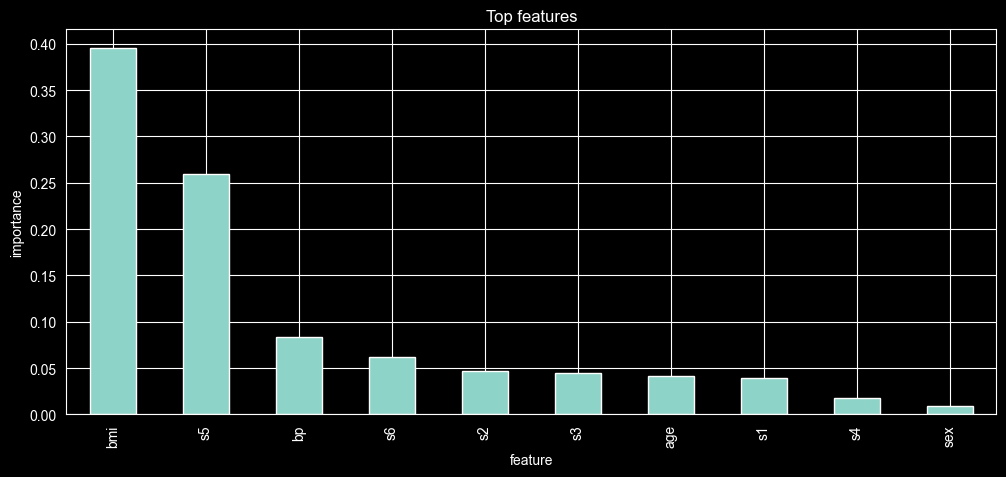

In [9]:
rf_importances = best_rf.named_steps["model"].feature_importances_

rf_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_importances
}).sort_values("importance", ascending=False)

rf_df

rf_df.set_index("feature")["importance"].head(10).plot(kind="bar", figsize=(12, 5))
plt.title("Top features")
plt.ylabel("importance")
plt.show()

## Выводы

- DecisionTreeRegressor может моделировать нелинейные зависимости, но легко переобучается.
- Переобучение видно через разницу между train MAE и test MAE.
- RandomForest обычно стабильнее одного дерева за счёт усреднения многих деревьев.
- GridSearchCV позволяет подобрать параметры леса через cross-validation.
- После tuning важно проверить модель на test-наборе.
- Feature importance показывает, какие признаки RandomForest чаще использовал для полезных разбиений.
- Tuning улучшил RandomForest, но прирост небольшой